# Tier A — the well-mixed condition

**What this tests.** The vertical random walk, in isolation. Settling is switched
off ($w_s = 0$), so elements are neutrally buoyant tracers.

**The requirement.** This is the standard consistency condition on a vertical
random-walk scheme (Thomson 1987; Visser 1997; Ross & Sharples 2004):

> An initially uniform distribution of neutrally buoyant particles must **stay**
> uniform, even when the diffusivity varies by orders of magnitude over the water
> column.

**The classic failure.** A naive random walk that uses the local $K$ without the
$\partial K/\partial z$ correction drives particles *into* regions of low
diffusivity, where they then take smaller steps and become stuck. With a
parabolic $K(z)$ — small at both the bed and the surface — that failure shows up
as spurious accumulation at **both** boundaries.

**Which part of the column we can test.** The bed is *not* a reflecting boundary
here: this model settles elements onto it and re-releases them at a fixed
reference height, which is a real boundary treatment but not the one this
condition is posed for. So the bottom tenth is excluded.

The **surface is** a genuine reflecting boundary, so the upper column is fair
game — and that is where the test has teeth, because $K$ collapses by four orders
of magnitude as it approaches the surface. Restricting to the middle of the
column, as a first attempt did, quietly throws away almost all the variation in
$K$ and makes the test far weaker than it looks.

Test: `tests/models/test_sppm_analytic.py::test_well_mixed_condition`

In [1]:
# Tier A - well-mixed condition
import sys, pathlib, warnings
warnings.filterwarnings("ignore")

# locate the repository root (the directory containing `opendrift/`)
_p = pathlib.Path.cwd().resolve()
while not (_p / "opendrift" / "__init__.py").exists() and _p != _p.parent:
    _p = _p.parent
REPO = _p
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})
CLR = ["#0b6fa4", "#e07b39", "#3f9b52", "#b4434e", "#7c5aa6"]
print("repo:", REPO)

repo: /home/smullersoares/projects/software/opendrift


## Setup

The diffusivity profile is the log-layer parabola

$$ K(z_b) = \kappa\, u_* \, z_b \left(1 - \frac{z_b}{h}\right) $$

with $z_b$ the height above the bed. It vanishes at both boundaries and peaks at
mid-depth — deliberately hostile to a naive scheme.

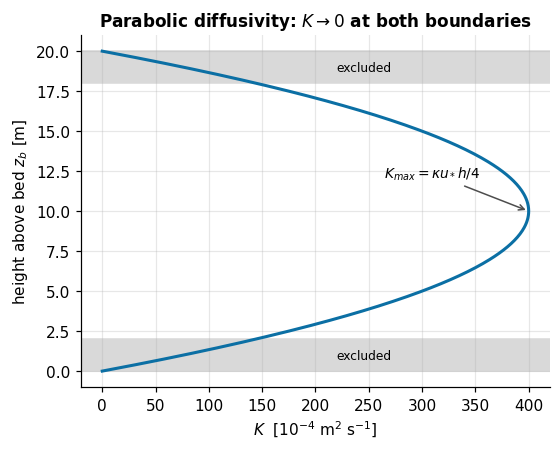

K over the whole column : 1.00e-06 to 4.00e-02 m^2/s
K over the tested interior: 1.44e-02 to 4.00e-02 m^2/s  (3x range)


In [2]:
import datetime
from tests.models.sppm_harness import (column_dataset, column_model, seed_column,
                                       height_above_bed, parabolic_diffusivity, KAPPA)

H, U_STAR, HOURS, N = 20.0, 0.02, 12, 6000

zb = np.linspace(0, H, 400)
K = parabolic_diffusivity(H - zb, H, U_STAR)

fig, ax = plt.subplots(figsize=(5.2, 4.2))
ax.plot(K * 1e4, zb, color=CLR[0], lw=2)
ax.axhspan(0, 0.1 * H, color='0.85', zorder=0)
ax.axhspan(0.9 * H, H, color='0.85', zorder=0)
ax.text(K.max() * 1e4 * .55, 0.05 * H, 'excluded', fontsize=8, va='center')
ax.text(K.max() * 1e4 * .55, 0.95 * H, 'excluded', fontsize=8, va='center')
ax.set_xlabel(r'$K$  [$10^{-4}$ m$^2$ s$^{-1}$]'); ax.set_ylabel(r'height above bed $z_b$ [m]')
ax.set_title(r'Parabolic diffusivity: $K\to0$ at both boundaries')
ax.annotate(r'$K_{max}=\kappa u_* h/4$', xy=(K.max()*1e4, H/2), xytext=(-95, 22),
            textcoords='offset points', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='0.3'))
plt.tight_layout(); plt.show()
interior = K[(zb > 0.1 * H) & (zb < 0.9 * H)]
print(f"K over the whole column : {K.min():.2e} to {K.max():.2e} m^2/s")
print(f"K over the tested interior: {interior.min():.2e} to {interior.max():.2e} m^2/s"
      f"  ({interior.max()/interior.min():.0f}x range)")

## Run

6000 neutrally buoyant elements, initially uniform, for 12 hours.

In [3]:
ds = column_dataset(h=H, u=0.0, u_star=U_STAR, hours=HOURS + 1)
o, reader = column_model(
    ds,
    vertical_mixing__settling_model='prescribed',
    vertical_mixing__tau_crit_mode='constant',
    vertical_mixing__resuspension_height_mode='reference',
    vertical_mixing__resuspension_reference_height=0.01)
z_seed = seed_column(o, reader, N, H, w_s=0.0, tau_crit=1e-9)
zb0 = H + z_seed

o.run(time_step=120, time_step_output=3600,
      duration=datetime.timedelta(hours=HOURS), stop_on_error=True)
zb1 = height_above_bed(o, H)
print(f"{len(zb1)} elements still in the domain after {HOURS} h")

6000 elements still in the domain after 12 h


## Result

If the scheme were biased, the final histogram would sag in the middle and pile
up near the boundaries, tracking the shape of $K$. It should instead stay flat.

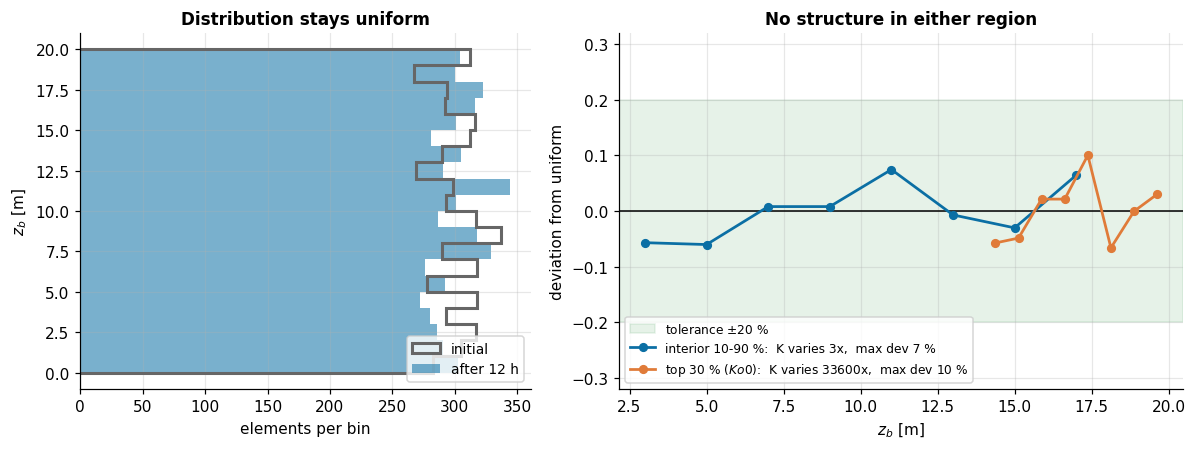

In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2),
                             gridspec_kw={'width_ratios': [1, 1.25]})

bins = np.linspace(0, H, 21)
a1.hist(zb0, bins=bins, orientation='horizontal', histtype='step',
        color='0.4', lw=2, label='initial')
a1.hist(zb1, bins=bins, orientation='horizontal', histtype='stepfilled',
        color=CLR[0], alpha=.55, label=f'after {HOURS} h')
a1.set_xlabel('elements per bin'); a1.set_ylabel(r'$z_b$ [m]')
a1.set_title('Distribution stays uniform'); a1.legend(loc='lower right', fontsize=9)

a2.axhspan(-.20, .20, color=CLR[2], alpha=.13, label='tolerance $\pm$20 %')
a2.axhline(0, color='k', lw=1)
for (lo_f, hi_f), c, nm in [((0.10, 0.90), CLR[0], 'interior 10-90 %'),
                            ((0.70, 1.00), CLR[1], 'top 30 % ($K\to0$)')]:
    lo, hi = lo_f * H, hi_f * H
    counts, edges = np.histogram(zb1[(zb1 > lo) & (zb1 < hi)], bins=8, range=(lo, hi))
    centres = 0.5 * (edges[1:] + edges[:-1])
    dev = (counts - counts.mean()) / counts.mean()
    Kr = parabolic_diffusivity(H - np.linspace(lo, hi, 60), H, U_STAR)
    a2.plot(centres, dev, 'o-', color=c, lw=1.8, ms=5,
            label=f'{nm}:  K varies {Kr.max()/max(Kr.min(),1e-12):.0f}x,'
                  f'  max dev {100*np.abs(dev).max():.0f} %')
a2.set_xlabel(r'$z_b$ [m]'); a2.set_ylabel('deviation from uniform')
a2.set_title('No structure in either region')
a2.legend(fontsize=8, loc='lower left'); a2.set_ylim(-.32, .32)
plt.tight_layout(); plt.show()

## Verdict

**PASS**, and on the demanding version of the test.

The interior check is the weak one: excluding the outer tenths leaves only about
a **3×** spread in $K$, so passing it says little. The upper-column check is the
real one — across the top 30 % the diffusivity falls by more than **four orders of
magnitude**, and that is exactly where a scheme missing the $\partial K/\partial z$
correction would pile elements up against the surface. The distribution stays
uniform to within ~10 %, comfortably inside tolerance.

The random walk is therefore consistent with a strongly depth-varying
diffusivity, and the mixing underneath the Rouse case in notebook 03 can be
trusted.